# Training semantic encoder

Goal: learn a shared latent space for paired scRNA + scATAC where:
1. embeddings capture biological semantics rather than technical noise,
2. modalities are aligned with contrastive learning,
3. neither modality dominates the joint representation.


In [1]:

import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba-cache")

import random
from dataclasses import dataclass
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    import mudata as mu
except ImportError:
    import muon as mu

sc = None


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "Squidiff").exists() and (cwd / "data").exists():
        return cwd
    if cwd.name == "scripts" and (cwd.parent / "Squidiff").exists():
        return cwd.parent
    return cwd


def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def matrix_summary(X, *, max_hist_values=500_000, rng_seed=42):
    n_values = int(np.prod(X.shape))
    if sp.issparse(X):
        data = np.asarray(X.data, dtype=np.float32)
        nnz = int(X.nnz)
        zero_fraction = 1.0 - (nnz / n_values if n_values else 0.0)
        if nnz:
            min_value = min(float(data.min()), 0.0) if zero_fraction > 0 else float(data.min())
            max_value = float(data.max())
            mean_value = float(data.sum() / n_values)
            second_moment = float(np.square(data, dtype=np.float64).sum() / n_values)
            std_value = float(max(second_moment - mean_value ** 2, 0.0) ** 0.5)
            if nnz > max_hist_values:
                rng = np.random.default_rng(rng_seed)
                hist_values = rng.choice(data, size=max_hist_values, replace=False)
            else:
                hist_values = data
        else:
            min_value = max_value = mean_value = std_value = 0.0
            hist_values = np.array([0.0], dtype=np.float32)
        return {
            "min": min_value,
            "max": max_value,
            "mean": mean_value,
            "std": std_value,
            "zero_fraction": float(zero_fraction),
            "hist_values": hist_values,
            "hist_note": "nonzero values only; zeros summarized separately",
        }

    x = np.asarray(X, dtype=np.float32)
    flat = x.ravel()
    if flat.size > max_hist_values:
        rng = np.random.default_rng(rng_seed)
        hist_values = rng.choice(flat, size=max_hist_values, replace=False)
    else:
        hist_values = flat
    return {
        "min": float(flat.min()),
        "max": float(flat.max()),
        "mean": float(flat.mean()),
        "std": float(flat.std()),
        "zero_fraction": float((flat == 0).mean()),
        "hist_values": hist_values,
        "hist_note": "sampled dense values" if flat.size > max_hist_values else "all dense values",
    }


def inspect_adata(adata, label: str, group_key: str | None = None):
    print(f"=== {label} ===")
    print(adata)
    print("X type:", type(adata.X))
    print("obs columns:", list(adata.obs.columns))
    print("var columns:", list(adata.var.columns))
    print("var_names head:", adata.var_names[:10].tolist())

    if group_key is not None and group_key in adata.obs.columns:
        print(f"{group_key} distribution:")
        print(adata.obs[group_key].value_counts(dropna=False).sort_index())

    summary_values = matrix_summary(adata.X)
    hist_values = summary_values.pop("hist_values")
    hist_note = summary_values.pop("hist_note")
    summary = pd.Series(
        {
            "n_obs": int(adata.n_obs),
            "n_vars": int(adata.n_vars),
            **summary_values,
        },
        name=label,
    )
    display(summary.to_frame())

    plt.figure(figsize=(6, 4))
    plt.hist(hist_values, bins=100, color="#4C78A8", alpha=0.85)
    plt.title(f"{label}: value distribution")
    plt.xlabel(f"Value ({hist_note})")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return summary


def first_existing_key(obs_df: pd.DataFrame, candidates):
    for key in candidates:
        if key in obs_df.columns:
            return key
    return None


def stratify_values(obs_df, key, indices):
    if key is None or key not in obs_df.columns:
        return None
    values = obs_df.iloc[indices][key].astype(str).to_numpy()
    _, counts = np.unique(values, return_counts=True)
    if len(counts) < 2 or counts.min() < 2:
        return None
    return values


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = resolve_repo_root()
print("device:", device)
print("REPO_ROOT:", REPO_ROOT)

WANDB_AVAILABLE = False


device: cuda
REPO_ROOT: /home/anniehuang/Squidiff


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mouse file exists: True
Mouse path: /home/anniehuang/Squidiff/data/mouse/processed/mouse_train.h5mu


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 9358 × 69575
  var:	'interval'
  uns:	'stage_to_group'
  2 modalities
    rna:	9358 × 2810
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg'
      layers:	'counts'
    atac:	9358 × 66765
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'interval', 'chrom', 'start', 'end'
      layers:	'counts'
Available modalities: ['rna', 'atac']
Paired cells: 9,358
RNA features: 2,810
ATAC features: 66,765
=== Mouse RNA train paired ===
AnnData object with n_obs × n_vars = 9358 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
    var: 'gene_ids', 'feature_types', 'genome

,Mouse RNA train paired
n_obs,9358.000000
n_vars,2810.000000
min,0.000000
max,8.065309
mean,0.196478
std,0.545761
zero_fraction,0.851320


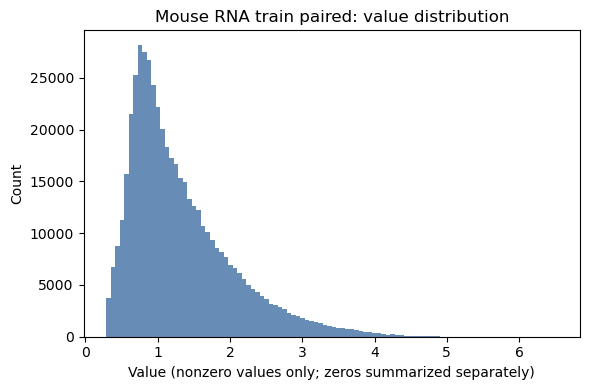

=== Mouse ATAC train paired ===
AnnData object with n_obs × n_vars = 9358 × 66765
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
    var: 'interval', 'chrom', 'start', 'end'
    layers: 'counts'
X type: <class 'scipy.sparse._csr.csr_matrix'>
obs columns: ['stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage']
var columns: ['interval', 'chrom', 'start', 'end']
var_names head: ['chr1:3670426-3671272', 'chr1:3671377-3672388', 'chr1:3913295-3914390', 'chr1:4491613-4492747', 'chr1:4496015-4497069', 'chr1:4497079-4498098', 'chr1:4571339-4572314', 'chr1:4768135-4769307', 'chr1:4769682-4770696', 'chr1:4785220-4786187']
Group distribution:
Group
0    5820
3    3538
Name: count, dtype: int64


,Mouse ATAC train paired
n_obs,9358.000000
n_vars,66765.000000
min,0.000000
max,15.936829
mean,0.105900
std,0.452117
zero_fraction,0.924485


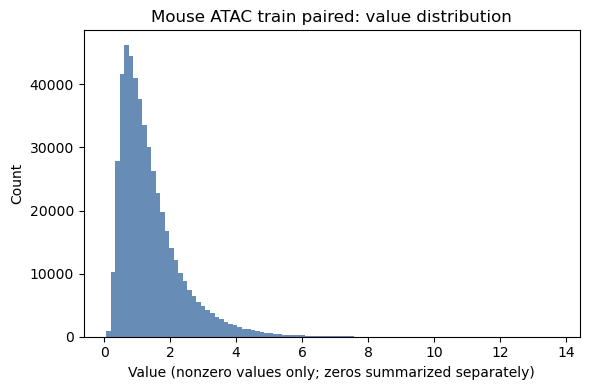

group_key: Group
day_key: stage
split_key: Group
Split sizes: {'train': 6550, 'val': 1404, 'test': 1404}


In [2]:

mouse_fn = REPO_ROOT / "data" / "mouse" / "processed" / "mouse_train.h5mu"
print("Mouse file exists:", mouse_fn.exists())
print("Mouse path:", mouse_fn)

mouse_mdata = mu.read_h5mu(mouse_fn)
print(mouse_mdata)
print("Available modalities:", list(mouse_mdata.mod.keys()))

required_modalities = {"rna", "atac"}
missing = required_modalities - set(mouse_mdata.mod.keys())
if missing:
    raise KeyError(f"Mouse h5mu is missing required modalities: {sorted(missing)}")

mouse_rna = mouse_mdata["rna"].copy()
mouse_atac = mouse_mdata["atac"].copy()
common_obs = mouse_rna.obs_names.intersection(mouse_atac.obs_names)
if len(common_obs) == 0:
    raise ValueError("RNA and ATAC modalities have no overlapping cell barcodes.")

rna = mouse_rna[common_obs].copy()
atac = mouse_atac[common_obs].copy()
if not np.array_equal(rna.obs_names.to_numpy(), atac.obs_names.to_numpy()):
    raise ValueError("RNA and ATAC obs_names are not aligned after common-cell subsetting.")

print(f"Paired cells: {rna.n_obs:,}")
print(f"RNA features: {rna.n_vars:,}")
print(f"ATAC features: {atac.n_vars:,}")

group_key = first_existing_key(rna.obs, ["Group", "group", "cell_type", "celltype"])
day_key = first_existing_key(rna.obs, ["Day", "day", "stage", "time", "batch_stage"])
split_key = group_key if group_key is not None else day_key

mouse_rna_summary = inspect_adata(rna, label="Mouse RNA train paired", group_key=group_key)
mouse_atac_summary = inspect_adata(atac, label="Mouse ATAC train paired", group_key=group_key)
print("group_key:", group_key)
print("day_key:", day_key)
print("split_key:", split_key)

all_idx = np.arange(rna.n_obs)
train_val_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=stratify_values(rna.obs, split_key, all_idx),
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.1765,
    random_state=42,
    shuffle=True,
    stratify=stratify_values(rna.obs, split_key, train_val_idx),
)

print("Split sizes:", {"train": len(train_idx), "val": len(val_idx), "test": len(test_idx)})
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)


## Data Overview

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class PairedEncoder(nn.Module):
    def __init__(self, rna_dim, atac_dim, latent_dim=64, 
                 hidden_rna=(512, 256), hidden_atac=(512, 256), dropout=0.1):
        super().__init__()
        self.rna_encoder = MLP(rna_dim, latent_dim, list(hidden_rna), dropout=dropout)
        self.atac_encoder = MLP(atac_dim, latent_dim, list(hidden_atac), dropout=dropout)
        self.rna_decoder = MLP(latent_dim, rna_dim, list(hidden_rna[::-1]), dropout=dropout)
        self.atac_decoder = MLP(latent_dim, atac_dim, list(hidden_atac[::-1]), dropout=dropout)

    def forward(self, x_rna, x_atac):
        z_rna = self.rna_encoder(x_rna)
        z_atac = self.atac_encoder(x_atac)
        p_rna = F.normalize(z_rna, dim=-1)
        p_atac = F.normalize(z_atac, dim=-1)
        x_atac_hat_from_rna = self.atac_decoder(z_rna)
        x_rna_hat_from_atac = self.rna_decoder(z_atac)
        return z_rna, z_atac, p_rna, p_atac, x_rna_hat_from_atac, x_atac_hat_from_rna

In [4]:
class PairedMultiomeDataset(Dataset):
    def __init__(self, rna_X, atac_X, indices):
        self.rna_X = rna_X
        self.atac_X = atac_X
        self.indices = np.asarray(indices)

    def _row_to_dense(self, X, i):
        row = X[i]
        if sp.issparse(row):
            row = row.toarray().squeeze(0)
        return np.asarray(row, dtype=np.float32)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        rna = self._row_to_dense(self.rna_X, i)
        atac = self._row_to_dense(self.atac_X, i)
        return torch.from_numpy(rna), torch.from_numpy(atac), i


def info_nce_loss(a, b, temperature=0.1):
    logits = a @ b.t() / temperature
    labels = torch.arange(a.size(0), device=a.device)
    loss_ab = F.cross_entropy(logits, labels)
    loss_ba = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_ab + loss_ba)


def variance_loss(z, eps=1e-4):
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(1 - std))


def covariance_loss(z):
    z = z - z.mean(dim=0)
    cov = (z.t() @ z) / (z.size(0) - 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return (off_diag ** 2).mean()


def modality_balance_loss(z_rna, z_atac):
    # Encourage similar latent scale/energy from both modalities.
    er = (z_rna ** 2).mean()
    ea = (z_atac ** 2).mean()
    return (torch.log(er + 1e-8) - torch.log(ea + 1e-8)).pow(2)


def knn_modality_mixing(z_joint, modality_labels, k=30):
    # Higher is better mixing across modalities (closer to 0.5 in two-modal setting).
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(z_joint))).fit(z_joint)
    inds = nbrs.kneighbors(z_joint, return_distance=False)
    inds = inds[:, 1:]
    neigh_mod = modality_labels[inds]
    center_mod = modality_labels[:, None]
    frac_other = (neigh_mod != center_mod).mean()
    return float(frac_other)


In [5]:
@dataclass
class TrainConfig:
    epochs: int = 100
    lr: float = 1e-3
    batch_size: int = 256
    patience: int = 10
    temperature: float = 0.1
    lambda_var: float = 0.1
    lambda_cov: float = 0.05
    lambda_balance: float = 0.2
    lambda_recon: float = 0.2
    chpt_pth: str = './ckpt/best.pt'


def build_loaders(rna_X, atac_X, train_idx, val_idx, test_idx, batch_size=256):
    train_ds = PairedMultiomeDataset(rna_X, atac_X, train_idx)
    val_ds = PairedMultiomeDataset(rna_X, atac_X, val_idx)
    test_ds = PairedMultiomeDataset(rna_X, atac_X, test_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)
    return train_loader, val_loader, test_loader


def training(model, train_loader, val_loader, obs_df, config: TrainConfig, project='mlp-semantic-encoder', run_name='paired-mlp'):
    os.makedirs(os.path.dirname(config.chpt_pth), exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val = float('inf')
    wait = 0
    history = []

    use_wandb = WANDB_AVAILABLE
    if use_wandb:
        wandb.init(project=project, name=run_name, config=config.__dict__, reinit=True)

    for epoch in range(config.epochs):
        model.train()
        train_losses = []

        for x_rna, x_atac, idx in train_loader:
            x_rna = x_rna.to(device)
            x_atac = x_atac.to(device)

            x_rna_aug = x_rna
            x_atac_aug = x_atac

            z_rna, z_atac, p_rna, p_atac, x_rna_hat, x_atac_hat = model(x_rna_aug, x_atac_aug)

            loss_contrastive = info_nce_loss(p_rna, p_atac, temperature=config.temperature)
            loss_var = variance_loss(z_rna) + variance_loss(z_atac)
            loss_cov = covariance_loss(z_rna) + covariance_loss(z_atac)
            loss_balance = modality_balance_loss(z_rna, z_atac)
            loss_recon = F.mse_loss(x_rna_hat, x_rna) + F.mse_loss(x_atac_hat, x_atac)

            loss = (
                loss_contrastive
                + config.lambda_var * loss_var
                + config.lambda_cov * loss_cov
                + config.lambda_balance * loss_balance
                + config.lambda_recon * loss_recon
            )

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_rna, x_atac, idx in val_loader:
                x_rna = x_rna.to(device)
                x_atac = x_atac.to(device)
                z_rna, z_atac, p_rna, p_atac, x_rna_hat, x_atac_hat = model(x_rna, x_atac)

                loss = (
                    info_nce_loss(p_rna, p_atac, temperature=config.temperature)
                    + config.lambda_var * (variance_loss(z_rna) + variance_loss(z_atac))
                    + config.lambda_cov * (covariance_loss(z_rna) + covariance_loss(z_atac))
                    + config.lambda_balance * modality_balance_loss(z_rna, z_atac)
                    + config.lambda_recon * (F.mse_loss(x_rna_hat, x_rna) + F.mse_loss(x_atac_hat, x_atac))
                )
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)

        rec = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(rec)

        if use_wandb:
            wandb.log(rec)

        print(f"Epoch {epoch+1:03d} | train {train_loss:.4f} | val {val_loss:.4f} | lr {rec['lr']:.2e}")

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            torch.save(model.state_dict(), config.chpt_pth)
        else:
            wait += 1
            if wait >= config.patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if use_wandb:
        wandb.finish()

    model.load_state_dict(torch.load(config.chpt_pth, map_location=device))
    return pd.DataFrame(history)


In [11]:

# Quick model candidates for sanity check
rna_dim = rna.n_vars
atac_dim = atac.n_vars

lr = 1e-3
epochs = 100
batch_size = 256

candidates = [
    PairedEncoder(rna_dim, atac_dim, latent_dim=32, hidden_rna=(256, 128), hidden_atac=(256, 128), dropout=0.1).to(device),
    PairedEncoder(rna_dim, atac_dim, latent_dim=64, hidden_rna=(512, 256), hidden_atac=(512, 256), dropout=0.1).to(device),
    PairedEncoder(rna_dim, atac_dim, latent_dim=128, hidden_rna=(1024, 512), hidden_atac=(1024, 512), dropout=0.2).to(device),
    PairedEncoder(rna_dim, atac_dim, latent_dim=128, hidden_rna=(512, 256, 128), hidden_atac=(512, 256, 128), dropout=0.2).to(device),
]

train_loader, val_loader, test_loader = build_loaders(
    rna.X, atac.X, train_idx, val_idx, test_idx, batch_size=batch_size
)

model = candidates[2]

cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    batch_size=batch_size,
    patience=12,
    temperature=0.1,
    lambda_var=0.1,
    lambda_cov=0.05,
    lambda_balance=1.0,
    lambda_recon=0.1,
    chpt_pth=str(REPO_ROOT / "checkpoints" / "best_mouse_semantic_encoder.pt"),
)

history_df = training(model, train_loader, val_loader, rna.obs, cfg, run_name="mouse-paired-base")
history_df.tail()


Epoch 001 | train 3.1984 | val 2.3913 | lr 1.00e-03
Epoch 002 | train 2.0510 | val 2.0874 | lr 1.00e-03
Epoch 003 | train 1.4108 | val 2.0485 | lr 1.00e-03
Epoch 004 | train 1.0865 | val 2.0606 | lr 1.00e-03
Epoch 005 | train 0.8466 | val 2.0475 | lr 1.00e-03
Epoch 006 | train 0.6950 | val 2.0955 | lr 1.00e-03
Epoch 007 | train 0.5922 | val 2.0519 | lr 1.00e-03
Epoch 008 | train 0.5284 | val 2.1723 | lr 1.00e-03
Epoch 009 | train 0.4829 | val 2.1451 | lr 5.00e-04
Epoch 010 | train 0.4358 | val 2.1687 | lr 5.00e-04
Epoch 011 | train 0.4011 | val 2.1780 | lr 5.00e-04
Epoch 012 | train 0.3820 | val 2.2148 | lr 5.00e-04
Epoch 013 | train 0.3655 | val 2.2272 | lr 2.50e-04
Epoch 014 | train 0.3506 | val 2.2415 | lr 2.50e-04
Epoch 015 | train 0.3373 | val 2.2446 | lr 2.50e-04
Epoch 016 | train 0.3320 | val 2.2551 | lr 2.50e-04
Epoch 017 | train 0.3255 | val 2.2813 | lr 1.25e-04
Early stopping at epoch 17


,epoch,train_loss,val_loss,lr
12,13,0.365496,2.227250,0.000250
13,14,0.350597,2.241537,0.000250
14,15,0.337306,2.244555,0.000250
15,16,0.332036,2.255136,0.000250
16,17,0.325548,2.281326,0.000125


In [12]:
def embed_dataset(model, loader):
    model.eval()
    z_rna_all, z_atac_all = [], []
    p_rna_all, p_atac_all = [], []
    ids_all = []
    with torch.no_grad():
        for x_rna, x_atac, idx in loader:
            x_rna = x_rna.to(device)
            x_atac = x_atac.to(device)
            z_rna, z_atac, p_rna, p_atac, _, _ = model(x_rna, x_atac)
            z_rna_all.append(z_rna.cpu().numpy())
            z_atac_all.append(z_atac.cpu().numpy())
            p_rna_all.append(p_rna.cpu().numpy())
            p_atac_all.append(p_atac.cpu().numpy())
            ids_all.append(idx.numpy())
    return (
        np.concatenate(z_rna_all, axis=0),
        np.concatenate(z_atac_all, axis=0),
        np.concatenate(p_rna_all, axis=0),
        np.concatenate(p_atac_all, axis=0),
        np.concatenate(ids_all, axis=0),
    )

# best_model = candidates[1]
# model.load_state_dict(torch.load('./ckpt/best_semantic_encoder.pt'))
z_rna_test, z_atac_test, p_rna_test, p_atac_test, ids_test = embed_dataset(model, test_loader)
t_rna_test, t_atac_test = p_rna_test, p_atac_test

# Alignment quality: paired cosine similarity should be high in both spaces.
paired_cos_z = np.sum(
    z_rna_test / (np.linalg.norm(z_rna_test, axis=1, keepdims=True) + 1e-8)
    * z_atac_test / (np.linalg.norm(z_atac_test, axis=1, keepdims=True) + 1e-8),
    axis=1,
)
print("Mean paired cosine similarity (z space):", float(paired_cos_z.mean()))

paired_cos_p = np.sum(
    p_rna_test / (np.linalg.norm(p_rna_test, axis=1, keepdims=True) + 1e-8)
    * p_atac_test / (np.linalg.norm(p_atac_test, axis=1, keepdims=True) + 1e-8),
    axis=1,
)
print("Mean paired cosine similarity (p/t space):", float(paired_cos_p.mean()))

# Modality balance checks.
rna_energy = float((z_rna_test ** 2).mean())
atac_energy = float((z_atac_test ** 2).mean())
print("RNA latent energy:", rna_energy)
print("ATAC latent energy:", atac_energy)
print("Energy ratio RNA/ATAC:", rna_energy / (atac_energy + 1e-8))

z_joint = np.vstack([z_rna_test, z_atac_test])
modality_labels = np.array([0] * len(z_rna_test) + [1] * len(z_atac_test))

mixing = knn_modality_mixing(z_joint, modality_labels, k=30)
print("kNN modality mixing (fraction of opposite-modality neighbors):", mixing)

# Lower silhouette by modality means less modality-driven separation.
sil = silhouette_score(z_joint, modality_labels)
print("Silhouette by modality (lower is better):", float(sil))


Mean paired cosine similarity (z space): 0.8066538572311401
Mean paired cosine similarity (p/t space): 0.8066539168357849
RNA latent energy: 1.1700818538665771
ATAC latent energy: 0.5835793614387512
Energy ratio RNA/ATAC: 2.0050089347433033
kNN modality mixing (fraction of opposite-modality neighbors): 0.3818138651471985
Silhouette by modality (lower is better): 0.027504244819283485


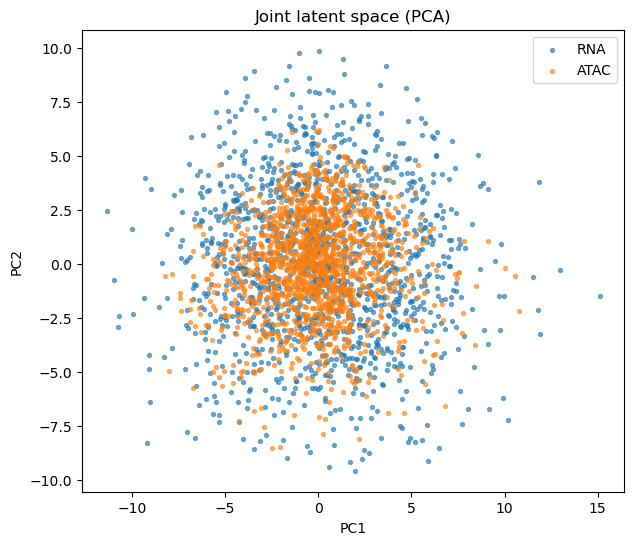

In [13]:
### Latent space visualization
# visualize the joint latent space

# 2D projection using PCA (works without extra dependencies)
pca = PCA(n_components=15, random_state=42)
z_2d = pca.fit_transform(z_joint)

plt.figure(figsize=(7, 6))
plt.scatter(z_2d[:len(z_rna_test), 0], z_2d[:len(z_rna_test), 1], s=8, alpha=0.6, label='RNA')
plt.scatter(z_2d[len(z_rna_test):, 0], z_2d[len(z_rna_test):, 1], s=8, alpha=0.6, label='ATAC')
plt.title('Joint latent space (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


/tmp/ipykernel_14271/552186264.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


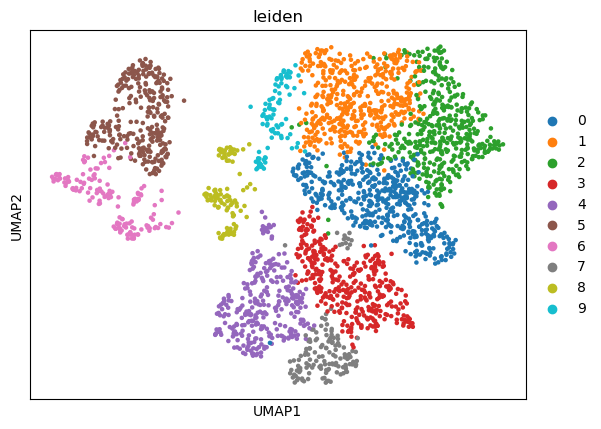

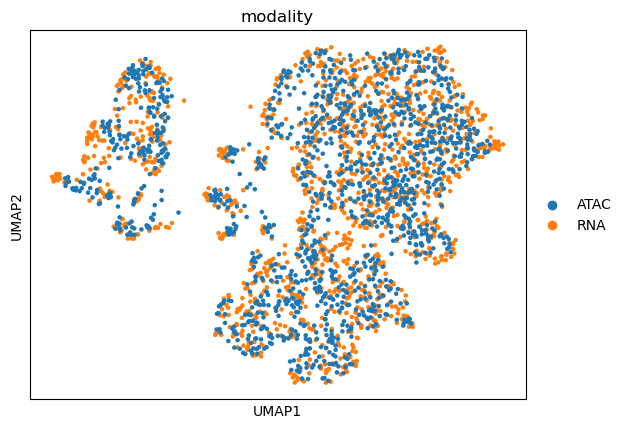

In [14]:
import scanpy as sc

# z_joint: shape [n_cells_total, latent_dim]
modality = np.array(
    ['RNA'] * len(z_rna_test) + ['ATAC'] * len(z_atac_test)
)

adata = ad.AnnData(X=z_joint)
adata.obs['modality'] = modality


sc.pp.pca(adata, n_comps=15)
sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=15)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)

# color by Leiden cluster
sc.pl.umap(adata, color=['leiden'], wspace=0.4)

# color by modality
sc.pl.umap(adata, color=['modality'], wspace=0.4)
